*this is where i'll work on the survey response data*

# 1) Clean & Tidy data 

This will take up the largest chunk of our time!


## Load Data & Packages

First let's load in and look at our raw data:

In [75]:
# import packages
import pandas as pd # for data manipulation
import numpy as np # for operations and uniforming data
import matplotlib.pyplot as plt # for data viz
import seaborn as sns #for data viz

# load raw data (this is a version of survey when there were 30 responses, but the column names are the same as the version with 50 responses, so we can use this for testing our code before we run it on the full dataset)

csv_file = '../data/raw/164_survey_total40.csv'
survey_raw_df = pd.read_csv(csv_file)

# view data
survey_raw_df.head()

,Timestamp,Score,First and Last Name,Email,Do you believe yourself to be Introverted or Extroverted?,What is your gender identity?,Which category best describes you? (select all that apply),What is your preferred music genre? (on a daily basis),"On a scale of 1-5, how introverted are you?\n(1 = introverted, 5 = extroverted)",How old are you?,...,"When you curate your party music playlist (even hypothetically), what is your intent for the party? For the people?",Why do you go to parties?,What is/are your ethnicity/ies?,What is/are your nationality/ ies?,"On a scale of 1-5, how likely are you are you to start a conversation with someone you don't know at a party with NO music sober?\n(1 = very unlikely, 5 = very likely)","On a scale of 1-5, how likely are you to start a conversation with someone you don't know at a house party with LOUD music sober?","Are you willing to participate in a short (anonymous) interview about your party experiences? (If yes, input your email)","Top 5 songs when hosting a party? If you have never hosted a party, please answer what you would put in your playlist!\n\n*Please specify song title and artist(s)!*","Have you ever gone to a party sober? (if yes, explain your experience with it: what you liked what surprised you vs. going to a party not sober, etc.)",Column 12
0,2/25/2026 12:10:43,NaN,NaN,NaN,NaN,Male,NaN,"Electronic, Pop",3,23,...,"singing, ambience with good vibes",To socialize with my friends and dance.,Latino,Meixcan-American,2,3,admontan@ucsd.edu,"Bad Bunny - Baile Inolvidable, Karol G - Si An...","Yes I have. While I feel more shy sometimes, i...",NaN
1,2/25/2026 12:19:46,NaN,NaN,NaN,NaN,Female,NaN,Hip Hop & R&B,2,20,...,Something to pump up or fill in the lack of en...,For free drinks foods or with my friends or to...,Vietnamese,American,1,3,No,"Any Daniel ceasar song, Melancholy Hill, Every...","Yes, I laughed more",NaN
2,2/25/2026 12:21:41,NaN,NaN,NaN,NaN,Female,NaN,"Hip Hop & R&B, Pop",4,21,...,dancing and ambience,"FOMO, friends are going and to take a break fr...",Hispanic,American,2,3,N/a,never hosted before but would put Spanish regg...,"Yes, I tried drinking but I ended up throwing ...",NaN
3,2/25/2026 12:32:51,NaN,NaN,NaN,NaN,female,NaN,"Hip Hop & R&B, Pop",3,19,...,reminiscing & singing,make memories & to have fun,Chinese/Vietnamese,American,4,2,no,"lady killers, 3 strikes, girlfriend heavy weig...",yes it was chill everybody was already in a ha...,NaN
4,2/25/2026 12:38:44,NaN,NaN,NaN,NaN,Female,NaN,"Metal/ Rock, Hip Hop & R&B, Pop",2,19,...,"I think having a playlist that is fun, nostalg...",Just to be with friends who are there and for ...,Vietnamese,American,3,2,No thank you,"I like all the stars by kendrick and sza, titi...",NaN,NaN


There's a bunch of columns that we actually don't need because no data ended up being needed to be recorded from them so I'll get rid of those:

In [76]:
# see column names
survey_raw_df.columns

Index(['Timestamp', 'Score', 'First and Last Name ', 'Email',
       'Do you believe yourself to be Introverted or Extroverted?',
       'What is your gender identity? ',
       'Which category best describes you? (select all that apply) ',
       'What is your preferred music genre? (on a daily basis) ',
       'On a scale of 1-5, how introverted are you?\n(1 = introverted, 5 = extroverted)',
       'How old are you? ', 'What is your college major? ', 'Email Address',
       'On a daily basis, what is the language of music you listen to? ',
       'What is your preferred music genre to listen to at parties? ',
       'What are your top 5 Artists for going out? ',
       'What are your top 5 songs before going out (this can be on your own or with others) (e.g., pregame, getting ready, etc.)? \n\n*Please specify song title and artist(s)!*',
       'What do you like about the parties you have gone to so far? (music, environment, loudness, etc. ) ',
       'What don't you like about parti

In [77]:
# removing columns that are not needed for analysis which are the ones with all missing values
survey_df = survey_raw_df.dropna(axis=1, how='all')

survey_df.head()


,Timestamp,What is your gender identity?,What is your preferred music genre? (on a daily basis),"On a scale of 1-5, how introverted are you?\n(1 = introverted, 5 = extroverted)",How old are you?,What is your preferred music genre to listen to at parties?,"What are your top 5 songs before going out (this can be on your own or with others) (e.g., pregame, getting ready, etc.)? \n\n*Please specify song title and artist(s)!*","What do you like about the parties you have gone to so far? (music, environment, loudness, etc. )","What don't you like about parties? (music, environment, loudness, etc. )","On a scale of 1-5, how likely are you to pregame before a party/gathering?\n(1 = very unlikely, 5 = very likely)",...,"On a scale of 1-5, how likely are you to sing along to a song at a party sober?\n(1 = very unlikely, 5 = very likely)","When you curate your party music playlist (even hypothetically), what is your intent for the party? For the people?",Why do you go to parties?,What is/are your ethnicity/ies?,What is/are your nationality/ ies?,"On a scale of 1-5, how likely are you are you to start a conversation with someone you don't know at a party with NO music sober?\n(1 = very unlikely, 5 = very likely)","On a scale of 1-5, how likely are you to start a conversation with someone you don't know at a house party with LOUD music sober?","Are you willing to participate in a short (anonymous) interview about your party experiences? (If yes, input your email)","Top 5 songs when hosting a party? If you have never hosted a party, please answer what you would put in your playlist!\n\n*Please specify song title and artist(s)!*","Have you ever gone to a party sober? (if yes, explain your experience with it: what you liked what surprised you vs. going to a party not sober, etc.)"
0,2/25/2026 12:10:43,Male,"Electronic, Pop",3,23,"Hip Hop & R&B, Pop","Rhianna - Where Have You Been, Bad Bunny - EoO...","I liked the music they've had, and the convers...",I don't like when others excessively use subst...,4,...,5,"singing, ambience with good vibes",To socialize with my friends and dance.,Latino,Meixcan-American,2,3,admontan@ucsd.edu,"Bad Bunny - Baile Inolvidable, Karol G - Si An...","Yes I have. While I feel more shy sometimes, i..."
1,2/25/2026 12:19:46,Female,Hip Hop & R&B,2,20,"Hip Hop & R&B, Electronic, Pop","Melancholy Hill, any Rocco song, Love Me Not, ...","The people there, the loudness","The environment, how parties always happe so late",2,...,5,Something to pump up or fill in the lack of en...,For free drinks foods or with my friends or to...,Vietnamese,American,1,3,No,"Any Daniel ceasar song, Melancholy Hill, Every...","Yes, I laughed more"
2,2/25/2026 12:21:41,Female,"Hip Hop & R&B, Pop",4,21,"Hip Hop & R&B, Electronic, Pop",any spanish reggaeton song or early 2000s pop ...,"music, dancing, and environment","If the music is bad, awkward people or not eno...",5,...,3,dancing and ambience,"FOMO, friends are going and to take a break fr...",Hispanic,American,2,3,N/a,never hosted before but would put Spanish regg...,"Yes, I tried drinking but I ended up throwing ..."
3,2/25/2026 12:32:51,female,"Hip Hop & R&B, Pop",3,19,"Hip Hop & R&B, Electronic, Pop","time to pretend mgmt, spin about you drake, lo...","music, chalant people, welcoming crowd",rude nonchalant people,2,...,1,reminiscing & singing,make memories & to have fun,Chinese/Vietnamese,American,4,2,no,"lady killers, 3 strikes, girlfriend heavy weig...",yes it was chill everybody was already in a ha...
4,2/25/2026 12:38:44,Female,"Metal/ Rock, Hip Hop & R&B, Pop",2,19,"Hip Hop & R&B, Pop","DtMF by bad bunny, luther by kendrick and sza,...",I like the music and just seeing the general h...,I don't typically like the drinking environmen...,1,...,5,"I think having a playlist that is fun, nostalg...",Just to be with friends who are there and for ...,Vietnamese,American,3,2,No thank you,"I like all the stars by kendrick and sza, titi...",NaN


## Renaming Columns

The column names are pretty long so I'll reformat them to be easier to call on and stuff:

In [78]:
# getting column names again after dropping columns and also seeing how many questions there are in the survey

i=0
for col in survey_df.columns:
    print(f"#{i}: {col}")
    i += 1

survey_df.columns.to_list()

#0: Timestamp
#1: What is your gender identity? 
#2: What is your preferred music genre? (on a daily basis) 
#3: On a scale of 1-5, how introverted are you?
(1 = introverted, 5 = extroverted)
#4: How old are you? 
#5: What is your preferred music genre to listen to at parties? 
#6: What are your top 5 songs before going out (this can be on your own or with others) (e.g., pregame, getting ready, etc.)? 

*Please specify song title and artist(s)!*
#7: What do you like about the parties you have gone to so far? (music, environment, loudness, etc. ) 
#8: What don't you like about parties? (music, environment, loudness, etc. ) 
#9: On a scale of 1-5, how likely are you to pregame before a party/gathering?
(1 = very unlikely, 5 = very likely)
#10: How many times have you gone to a gathering in the last 2 months?
#11: What emotions do you feel when listening to these top 5 songs?
#12: On a scale of 1-5, how likely are you to come up to a stranger at a party sober? 
(1 = very unlikely, 5 = ver

['Timestamp',
 'What is your gender identity? ',
 'What is your preferred music genre? (on a daily basis) ',
 'On a scale of 1-5, how introverted are you?\n(1 = introverted, 5 = extroverted)',
 'How old are you? ',
 'What is your preferred music genre to listen to at parties? ',
 'What are your top 5 songs before going out (this can be on your own or with others) (e.g., pregame, getting ready, etc.)? \n\n*Please specify song title and artist(s)!*',
 'What do you like about the parties you have gone to so far? (music, environment, loudness, etc. ) ',
 "What don't you like about parties? (music, environment, loudness, etc. ) ",
 'On a scale of 1-5, how likely are you to pregame before a party/gathering?\n(1 = very unlikely, 5 = very likely)',
 'How many times have you gone to a gathering in the last 2 months?',
 'What emotions do you feel when listening to these top 5 songs?',
 'On a scale of 1-5, how likely are you to come up to a stranger at a party sober? \n(1 = very unlikely, 5 = ver

In [79]:
# change column names to be more descriptive and easier to work with
survey_df = survey_df.rename(columns={

    # Demographics
    'What is your gender identity? ': 'gender',
    'How old are you? ': 'age',
    'What is/are your ethnicity/ies?': 'ethnicity',
    'What is/are your nationality/ ies?': 'nationality',
    'On a scale of 1-5, how introverted are you?\n(1 = introverted, 5 = extroverted)': 'introversion_score',

    # Music Preferences
    'What is your preferred music genre? (on a daily basis) ': 'preferred_genre_daily', 
    'What is your preferred music genre to listen to at parties? ': 'preferred_genre_parties',
    'What are your top 5 songs before going out (this can be on your own or with others) (e.g., pregame, getting ready, etc.)? \n\n*Please specify song title and artist(s)!*': 'top_5_songs_before_going_out',
    'What emotions do you feel when listening to these top 5 songs?': 'emotions_top_5_songs',
    'Top 5 songs when hosting a party? If you have never hosted a party, please answer what you would put in your playlist!\n\n*Please specify song title and artist(s)!*': 'top_5_songs_when_hosting_party',    
    'When you curate your party music playlist (even hypothetically), what is your intent for the party? For the people?': 'party_playlist_intent',

    # Party Experiences
    'Have you ever gone to a party sober? (if yes, explain your experience with it: what you liked what surprised you vs. going to a party not sober, etc.)': 'party_experience_sober',
    'On a scale of 1-5, how likely are you to pregame before a party/gathering?\n(1 = very unlikely, 5 = very likely)': 'pregame_likelihood_score',
    'How many times have you gone to a gathering in the last 2 months?': 'times_in_last_2_months',
    'On a scale of 1-5, how likely are you to come up to a stranger at a party sober? \n(1 = very unlikely, 5 = very likely)': 'likelihood_approach_stranger_score',
    'On a scale of 1-5, how likely are you to sing along to a song at a party sober?\n(1 = very unlikely, 5 = very likely)': 'likelihood_sing_along_score',
    "On a scale of 1-5, how likely are you are you to start a conversation with someone you don't know at a party with NO music sober?\n(1 = very unlikely, 5 = very likely)": 'likelihood_conversation_no_music_score',
    "On a scale of 1-5, how likely are you to start a conversation with someone you don't know at a house party with LOUD music sober?": 'likelihood_conversation_loud_music_score',
    'Why do you go to parties?': 'reason_for_going_to_parties',
    'What do you like about the parties you have gone to so far? (music, environment, loudness, etc. ) ': 'party_likes',
    "What don't you like about parties? (music, environment, loudness, etc. ) ": 'parties_dislikes',

    # Interview Participation
    'Are you willing to participate in a short (anonymous) interview about your party experiences? (If yes, input your email)': 'interview_participation_email',
})

#let's look at the dataframe again after renaming the columns:
survey_df.head()

,Timestamp,gender,preferred_genre_daily,introversion_score,age,preferred_genre_parties,top_5_songs_before_going_out,party_likes,parties_dislikes,pregame_likelihood_score,...,likelihood_sing_along_score,party_playlist_intent,reason_for_going_to_parties,ethnicity,nationality,likelihood_conversation_no_music_score,likelihood_conversation_loud_music_score,interview_participation_email,top_5_songs_when_hosting_party,party_experience_sober
0,2/25/2026 12:10:43,Male,"Electronic, Pop",3,23,"Hip Hop & R&B, Pop","Rhianna - Where Have You Been, Bad Bunny - EoO...","I liked the music they've had, and the convers...",I don't like when others excessively use subst...,4,...,5,"singing, ambience with good vibes",To socialize with my friends and dance.,Latino,Meixcan-American,2,3,admontan@ucsd.edu,"Bad Bunny - Baile Inolvidable, Karol G - Si An...","Yes I have. While I feel more shy sometimes, i..."
1,2/25/2026 12:19:46,Female,Hip Hop & R&B,2,20,"Hip Hop & R&B, Electronic, Pop","Melancholy Hill, any Rocco song, Love Me Not, ...","The people there, the loudness","The environment, how parties always happe so late",2,...,5,Something to pump up or fill in the lack of en...,For free drinks foods or with my friends or to...,Vietnamese,American,1,3,No,"Any Daniel ceasar song, Melancholy Hill, Every...","Yes, I laughed more"
2,2/25/2026 12:21:41,Female,"Hip Hop & R&B, Pop",4,21,"Hip Hop & R&B, Electronic, Pop",any spanish reggaeton song or early 2000s pop ...,"music, dancing, and environment","If the music is bad, awkward people or not eno...",5,...,3,dancing and ambience,"FOMO, friends are going and to take a break fr...",Hispanic,American,2,3,N/a,never hosted before but would put Spanish regg...,"Yes, I tried drinking but I ended up throwing ..."
3,2/25/2026 12:32:51,female,"Hip Hop & R&B, Pop",3,19,"Hip Hop & R&B, Electronic, Pop","time to pretend mgmt, spin about you drake, lo...","music, chalant people, welcoming crowd",rude nonchalant people,2,...,1,reminiscing & singing,make memories & to have fun,Chinese/Vietnamese,American,4,2,no,"lady killers, 3 strikes, girlfriend heavy weig...",yes it was chill everybody was already in a ha...
4,2/25/2026 12:38:44,Female,"Metal/ Rock, Hip Hop & R&B, Pop",2,19,"Hip Hop & R&B, Pop","DtMF by bad bunny, luther by kendrick and sza,...",I like the music and just seeing the general h...,I don't typically like the drinking environmen...,1,...,5,"I think having a playlist that is fun, nostalg...",Just to be with friends who are there and for ...,Vietnamese,American,3,2,No thank you,"I like all the stars by kendrick and sza, titi...",NaN


In [80]:
# and let's look at the column names again to make sure they are correct:
survey_df.columns.to_list(), len(survey_df.columns)

(['Timestamp',
  'gender',
  'preferred_genre_daily',
  'introversion_score',
  'age',
  'preferred_genre_parties',
  'top_5_songs_before_going_out',
  'party_likes',
  'parties_dislikes',
  'pregame_likelihood_score',
  'times_in_last_2_months',
  'emotions_top_5_songs',
  'likelihood_approach_stranger_score',
  'likelihood_sing_along_score',
  'party_playlist_intent',
  'reason_for_going_to_parties',
  'ethnicity',
  'nationality',
  'likelihood_conversation_no_music_score',
  'likelihood_conversation_loud_music_score',
  'interview_participation_email',
  'top_5_songs_when_hosting_party',
  'party_experience_sober'],
 23)

So minus the timestamp, there's 22 questions total.

### Adding Participant # Column
We also don't have a participant # column, which would be nice for seeing who said what, so let's add it:

In [81]:
# adding a participant_id column to uniquely identify each participant and make it easier to work with the data:
survey_df.insert(0, 'participant_id', range(1, len(survey_df) + 1))

In [82]:
# let's look at the dataframe again after adding the participant_id column:
survey_df.head()

,participant_id,Timestamp,gender,preferred_genre_daily,introversion_score,age,preferred_genre_parties,top_5_songs_before_going_out,party_likes,parties_dislikes,...,likelihood_sing_along_score,party_playlist_intent,reason_for_going_to_parties,ethnicity,nationality,likelihood_conversation_no_music_score,likelihood_conversation_loud_music_score,interview_participation_email,top_5_songs_when_hosting_party,party_experience_sober
0,1,2/25/2026 12:10:43,Male,"Electronic, Pop",3,23,"Hip Hop & R&B, Pop","Rhianna - Where Have You Been, Bad Bunny - EoO...","I liked the music they've had, and the convers...",I don't like when others excessively use subst...,...,5,"singing, ambience with good vibes",To socialize with my friends and dance.,Latino,Meixcan-American,2,3,admontan@ucsd.edu,"Bad Bunny - Baile Inolvidable, Karol G - Si An...","Yes I have. While I feel more shy sometimes, i..."
1,2,2/25/2026 12:19:46,Female,Hip Hop & R&B,2,20,"Hip Hop & R&B, Electronic, Pop","Melancholy Hill, any Rocco song, Love Me Not, ...","The people there, the loudness","The environment, how parties always happe so late",...,5,Something to pump up or fill in the lack of en...,For free drinks foods or with my friends or to...,Vietnamese,American,1,3,No,"Any Daniel ceasar song, Melancholy Hill, Every...","Yes, I laughed more"
2,3,2/25/2026 12:21:41,Female,"Hip Hop & R&B, Pop",4,21,"Hip Hop & R&B, Electronic, Pop",any spanish reggaeton song or early 2000s pop ...,"music, dancing, and environment","If the music is bad, awkward people or not eno...",...,3,dancing and ambience,"FOMO, friends are going and to take a break fr...",Hispanic,American,2,3,N/a,never hosted before but would put Spanish regg...,"Yes, I tried drinking but I ended up throwing ..."
3,4,2/25/2026 12:32:51,female,"Hip Hop & R&B, Pop",3,19,"Hip Hop & R&B, Electronic, Pop","time to pretend mgmt, spin about you drake, lo...","music, chalant people, welcoming crowd",rude nonchalant people,...,1,reminiscing & singing,make memories & to have fun,Chinese/Vietnamese,American,4,2,no,"lady killers, 3 strikes, girlfriend heavy weig...",yes it was chill everybody was already in a ha...
4,5,2/25/2026 12:38:44,Female,"Metal/ Rock, Hip Hop & R&B, Pop",2,19,"Hip Hop & R&B, Pop","DtMF by bad bunny, luther by kendrick and sza,...",I like the music and just seeing the general h...,I don't typically like the drinking environmen...,...,5,"I think having a playlist that is fun, nostalg...",Just to be with friends who are there and for ...,Vietnamese,American,3,2,No thank you,"I like all the stars by kendrick and sza, titi...",NaN


In [83]:
# save the cleaned data to a new csv file in the interim data folder:
survey_df.to_csv('../data/interim/survey_cleaned_labels.csv', index=False)

## Brief Section Summary:

**So far, we've...**
- loaded in the original raw data
- gotten rid of columns will all-missing values (they were from a prototype version of the survey)
- renamed columns to shorter labels to call them and see them easier
- added a `participant_id` column
- saved this new version of the raw data to an interim version called `survey_cleaned_labels.csv`

*Now* we'll begin **cleaning** this interim data.

## Cleaning Survey Data

Now we wanna make sure our data is pretty clean, meaning there's no substantial amounts of missing values and see if responses are what they should be. To be honest, there shouldn't be many missing values since most questions are required (other than "Have you ever gone to a party sober? (if yes, explain your experience with it: what you liked what surprised you vs. going to a party not sober, etc.) and something else I think?)

So let's load in our new interim data and assign it to datafram called `survey_clean_df`, where we'll save a clean version of the data later:

In [84]:
interim_csv_file = '../data/interim/survey_cleaned_labels.csv'
survey_clean_df = pd.read_csv(interim_csv_file)
survey_clean_df.head()

,participant_id,Timestamp,gender,preferred_genre_daily,introversion_score,age,preferred_genre_parties,top_5_songs_before_going_out,party_likes,parties_dislikes,...,likelihood_sing_along_score,party_playlist_intent,reason_for_going_to_parties,ethnicity,nationality,likelihood_conversation_no_music_score,likelihood_conversation_loud_music_score,interview_participation_email,top_5_songs_when_hosting_party,party_experience_sober
0,1,2/25/2026 12:10:43,Male,"Electronic, Pop",3,23,"Hip Hop & R&B, Pop","Rhianna - Where Have You Been, Bad Bunny - EoO...","I liked the music they've had, and the convers...",I don't like when others excessively use subst...,...,5,"singing, ambience with good vibes",To socialize with my friends and dance.,Latino,Meixcan-American,2,3,admontan@ucsd.edu,"Bad Bunny - Baile Inolvidable, Karol G - Si An...","Yes I have. While I feel more shy sometimes, i..."
1,2,2/25/2026 12:19:46,Female,Hip Hop & R&B,2,20,"Hip Hop & R&B, Electronic, Pop","Melancholy Hill, any Rocco song, Love Me Not, ...","The people there, the loudness","The environment, how parties always happe so late",...,5,Something to pump up or fill in the lack of en...,For free drinks foods or with my friends or to...,Vietnamese,American,1,3,No,"Any Daniel ceasar song, Melancholy Hill, Every...","Yes, I laughed more"
2,3,2/25/2026 12:21:41,Female,"Hip Hop & R&B, Pop",4,21,"Hip Hop & R&B, Electronic, Pop",any spanish reggaeton song or early 2000s pop ...,"music, dancing, and environment","If the music is bad, awkward people or not eno...",...,3,dancing and ambience,"FOMO, friends are going and to take a break fr...",Hispanic,American,2,3,N/a,never hosted before but would put Spanish regg...,"Yes, I tried drinking but I ended up throwing ..."
3,4,2/25/2026 12:32:51,female,"Hip Hop & R&B, Pop",3,19,"Hip Hop & R&B, Electronic, Pop","time to pretend mgmt, spin about you drake, lo...","music, chalant people, welcoming crowd",rude nonchalant people,...,1,reminiscing & singing,make memories & to have fun,Chinese/Vietnamese,American,4,2,no,"lady killers, 3 strikes, girlfriend heavy weig...",yes it was chill everybody was already in a ha...
4,5,2/25/2026 12:38:44,Female,"Metal/ Rock, Hip Hop & R&B, Pop",2,19,"Hip Hop & R&B, Pop","DtMF by bad bunny, luther by kendrick and sza,...",I like the music and just seeing the general h...,I don't typically like the drinking environmen...,...,5,"I think having a playlist that is fun, nostalg...",Just to be with friends who are there and for ...,Vietnamese,American,3,2,No thank you,"I like all the stars by kendrick and sza, titi...",NaN


### Missing Values
let's first check for missing values

In [85]:
# checking missing values in each column
survey_clean_df.isnull().sum()

participant_id                              0
Timestamp                                   0
gender                                      0
preferred_genre_daily                       0
introversion_score                          0
age                                         0
preferred_genre_parties                     0
top_5_songs_before_going_out                0
party_likes                                 0
parties_dislikes                            0
pregame_likelihood_score                    0
times_in_last_2_months                      0
emotions_top_5_songs                        0
likelihood_approach_stranger_score          0
likelihood_sing_along_score                 0
party_playlist_intent                       0
reason_for_going_to_parties                 0
ethnicity                                   1
nationality                                 1
likelihood_conversation_no_music_score      0
likelihood_conversation_loud_music_score    0
interview_participation_email     

Interview participation email has 7 missing values and party_experience_sober also hs 4 missing values, but those are optional, so it makes sense.

But why would top_5_songs_when_hosting_party, ethnicity, *and* nationality have 1 missing  value each? Those shouldn't be optional. Let's take a look:

In [86]:
# let's look at the missing values in top_5_songs_when_hosting_party, ethnicity, and nationality columns to see if there are any patterns in the missing data:

survey_clean_df[['participant_id', 'top_5_songs_when_hosting_party', 'ethnicity', 'nationality']]

,participant_id,top_5_songs_when_hosting_party,ethnicity,nationality
0,1,"Bad Bunny - Baile Inolvidable, Karol G - Si An...",Latino,Meixcan-American
1,2,"Any Daniel ceasar song, Melancholy Hill, Every...",Vietnamese,American
2,3,never hosted before but would put Spanish regg...,Hispanic,American
3,4,"lady killers, 3 strikes, girlfriend heavy weig...",Chinese/Vietnamese,American
4,5,"I like all the stars by kendrick and sza, titi...",Vietnamese,American
5,6,"talk talk - charli xcx, stateside + bladee - p...",asian,american
6,7,"latch- disclosure, doses&mimosas- cherub, savi...",vietnamese,american
7,8,I have no idea,Filipino,American
8,9,"All I Ever Asked by Rachel Chinouriri, Love is...",Southeast Asian; Vietnamese,USA
9,10,"deep in it by berlioz, breezy (inst.) by rolle...",hispanic/latino/mexican,american


Ok so looks like particpant 15 (row 14) has the missing value for top_5_songs_when_hosting_party and participant 34 (row 33) has the missing values for ethnicity/ nationality.

When I looked at the [original data](https://docs.google.com/spreadsheets/d/1nEbwnQkIQDKFjwbQ1KAeKQKjasBxnXfwjo9kEh9Fz9g/edit?resourcekey=&gid=601220780#gid=601220780) looks like they marked those sections with 'N/A' maybe?

Anyway I think the missing values we have aren't a big deal so I'll go ahead and **keep it as is**. now we wanna tidy up the data!

### Cleaning responses & Uniforming Data

#### Gender Clean-up
Ok so clearly people don't know what nationality vs ethnicity is so we're gonna have to clean that up a bit or change it to race I honestly don't know lol.

Also for the `gender` data, people also clearly don't know the difference b/w sex and gender lol. Most ppl wrote 'female' or 'male' so maybe we can clean it up by just standardizing the responses to sex? but there were some entries like 'gender fluid (fem) and for some reason 'Straight' bruhhh

In [87]:
# first will make gender column uniform by changing all values to lowercase and removing extra spaces
survey_clean_df['gender'] = survey_clean_df['gender'].str.lower().str.strip()

# now let's see what unique values there are in the gender column to see if there are any other variations of the same gender:
survey_clean_df['gender'].unique()

array(['male', 'female', 'genderfluid (fem)', 'heterosexual female',
       'she/her female', 'men', 'she/her', 'women', 'straight', 'woman'],
      dtype=object)

**1) 'man'**

Ok so for males, there is 'male' & 'men' still. We could either standardize to make anything listed as that as either 'male' or 'men' --> the correct response for gender would be 'men'

**2) 'woman'**

For 'female' there's a lot of unqiue entries essentially saying the same thing, including 'heterosexual female', 'she/her female', and 'she/her'

**3) 'non-binary'**

There's only one response that could fit this called 'genderfluid (fem)'

*So now let's just write some code to standardize the data to gender:*

In [88]:
# we're going to standardize the gender column by replacing all variations of the same categories ('woman', 'man', 'genderfluid') to the same value, and then we will reassign them to the gender column:
for gender in survey_clean_df['gender']:
    if 'woman' in gender or 'she/her' in gender or 'female' in gender:
        survey_clean_df['gender'] = survey_clean_df['gender'].replace(gender, 'woman')
    elif 'man' in gender or 'men' in gender or 'male' in gender or 'he/him' in gender:
        survey_clean_df['gender'] = survey_clean_df['gender'].replace(gender, 'man')
    elif 'genderfluid' in gender or 'non-binary' in gender or 'they/them' in gender:
        survey_clean_df['gender'] = survey_clean_df['gender'].replace(gender, 'non-binary')
    elif 'straight' in gender:
        survey_clean_df['gender'] = survey_clean_df['gender'].replace(gender, 'other/unknown')

# let's check the unique values again to make sure they are standardized:
survey_clean_df['gender'].unique()

array(['man', 'woman', 'non-binary', 'other/unknown'], dtype=object)

In [89]:
# ok let's also see how many of each unique value there is gender:
survey_clean_df['gender'].value_counts()

gender
woman            32
man               6
non-binary        1
other/unknown     1
Name: count, dtype: int64

Ok so now we have 4 categories for gender: 'man', 'woman', 'non-binary', and 'other/unknown' for the gender column!

**FYI the 'other' value is literally just that one person who put 'straight'**

#### Nationality/ Ethnicity Clean-Up

People also apparently don't know the difference b/w nationality aand ethnicity sooo lemme clean that up

In [90]:
# lemme group by the nationality and ethnicity columns to see the unique values in each column and how many people belong to each category:
survey_clean_df.groupby('nationality')['ethnicity'].value_counts()

nationality                ethnicity                     
American                   Vietnamese                        3
                           Korean                            2
                           Asian                             1
                           Bangladeshi                       1
                           Filipino                          1
                           Kurdish                           1
                           Mexican                           1
American                   Hispanic                          2
                           African American and Hispanic     1
                           Chinese/Vietnamese                1
American and Mexican       Hispanic                          1
Asian American             Vietnamese                        1
Chinese                    Asian                             1
Hispanic                   Mexican - American                1
Kazakh                     Kazakh                           

hmm ok so maybe the best way to group and standardize this data is just by race..

right off the bat i see a lot of "Hispanic" and "Asian" so let's start there:

In [91]:
# first let's standardize the formatting for ethnicity and nationality columns by changing all values to lowercase and removing extra spaces:

survey_clean_df['ethnicity'] = survey_clean_df['ethnicity'].str.lower().str.strip()
survey_clean_df['nationality'] = survey_clean_df['nationality'].str.lower().str.strip()

# fix obvious typos too
survey_clean_df['nationality'] = survey_clean_df['nationality'].replace('meixcan-american', 'mexican-american')

# grouping values again
survey_clean_df.groupby('nationality')['ethnicity'].value_counts()

nationality                ethnicity                    
american                   vietnamese                       6
                           asian                            2
                           hispanic                         2
                           korean                           2
                           african american and hispanic    1
                           bangladeshi                      1
                           chinese/vietnamese               1
                           filipino                         1
                           hispanic/latino/mexican          1
                           indian                           1
                           kurdish                          1
                           mexican                          1
american and mexican       hispanic                         1
asian american             vietnamese                       1
chinese                    asian                            1
hispanic     

In [92]:
# ;et's look at the unique values in the nationality
survey_clean_df['nationality'].unique()

array(['mexican-american', 'american', 'usa', 'salvadoran and guatemalan',
       'idk', 'taiwanese, american', 'asian american', 'mexican',
       'native', 'chinese', 'mexican american', 'latino', 'vietnamese',
       'american and mexican', 'hispanic', nan, 'kazakh'], dtype=object)

In [93]:
# unique values in ethnicity
survey_clean_df['ethnicity'].unique()

array(['latino', 'vietnamese', 'hispanic', 'chinese/vietnamese', 'asian',
       'filipino', 'southeast asian; vietnamese',
       'hispanic/latino/mexican', 'chinese',
       'african american and hispanic', 'none', 'hispanic/mexican',
       'bangladeshi', 'mexican', 'korean', 'white', 'mexican - american',
       'latina', nan, 'hispanic/latinx', 'indian', 'kazakh', 'kurdish'],
      dtype=object)

ok, firstly, there's a lot of repeats, so let's fix those:

In [94]:
# standardize the duplicate values in nationality:
survey_clean_df['nationality'] = survey_clean_df['nationality'].replace({
    'usa': 'american',
    'asian american': 'american',
    'mexican american': 'mexican-american',
    'american and mexican': 'mexican-american',
    'taiwanese, american': 'taiwanese-american',
    'idk': 'unknown'
})

survey_clean_df['nationality'].unique()

array(['mexican-american', 'american', 'salvadoran and guatemalan',
       'unknown', 'taiwanese-american', 'mexican', 'native', 'chinese',
       'latino', 'vietnamese', 'hispanic', nan, 'kazakh'], dtype=object)

In [95]:
# standardize duplicates in ethnicity:
survey_clean_df['ethnicity'] = survey_clean_df['ethnicity'].replace({
    'latina': 'latino',
    'hispanic/latinx': 'latino',
    'hispanic/latino/mexican': 'latino',
    'hispanic/mexican': 'latino',
    'mexican - american': 'mexican',
    'none': 'unknown'
})

survey_clean_df['ethnicity'].unique()

array(['latino', 'vietnamese', 'hispanic', 'chinese/vietnamese', 'asian',
       'filipino', 'southeast asian; vietnamese', 'chinese',
       'african american and hispanic', 'unknown', 'bangladeshi',
       'mexican', 'korean', 'white', nan, 'indian', 'kazakh', 'kurdish'],
      dtype=object)

In [96]:
# grouping by nationality and ethnicity again to see the unique values in each column and how many people belong to each category:
survey_clean_df.groupby('nationality')['ethnicity'].value_counts()

nationality                ethnicity                    
american                   vietnamese                       7
                           asian                            2
                           hispanic                         2
                           korean                           2
                           african american and hispanic    1
                           bangladeshi                      1
                           chinese/vietnamese               1
                           filipino                         1
                           indian                           1
                           kurdish                          1
                           latino                           1
                           mexican                          1
                           southeast asian; vietnamese      1
chinese                    asian                            1
hispanic                   mexican                          1
kazakh       

In [97]:
def assign_race_ethnicity(row):
    eth = str(row['ethnicity']).lower().strip() if pd.notna(row['ethnicity']) else ''
    nat = str(row['nationality']).lower().strip() if pd.notna(row['nationality']) else ''
    
    # multiracial indicators — only check ethnicity for this, not nationality
    multiracial_indicators = ['/', ';', ' and ', 'mixed']
    if any(x in eth for x in multiracial_indicators):
        return 'multiracial'
    
    # define keyword lists
    latine_keywords = ['latino', 'latina', 'latinx', 'hispanic', 'mexican', 'salvadoran', 'guatemalan', 'latine']
    asian_keywords = ['vietnamese', 'chinese', 'korean', 'filipino', 'bangladeshi', 'indian', 'asian', 'taiwanese', 'kazakh', 'kurdish']
    black_keywords = ['african', 'black']
    white_keywords = ['white', 'caucasian', 'european']
    indigenous_keywords = ['native', 'indigenous']

    # check ethnicity first (more reliable signal than nationality)
    for label, keywords in [
        ('latine/hispanic', latine_keywords),
        ('asian', asian_keywords),
        ('black', black_keywords),
        ('white', white_keywords),
        ('indigenous/native', indigenous_keywords)
    ]:
        if any(k in eth for k in keywords):
            # override: if ethnicity is 'white' but nationality is latine, prioritize latine
            if label == 'white' and any(k in nat for k in latine_keywords):
                return 'latine/hispanic'
            return label

    # fall back to nationality if ethnicity is empty/unknown
    for label, keywords in [
        ('latine/hispanic', latine_keywords),
        ('asian', asian_keywords),
    ]:
        if any(k in nat for k in keywords):
            return label

    return 'other/unknown'

survey_clean_df['race_ethnicity'] = survey_clean_df.apply(assign_race_ethnicity, axis=1)
survey_clean_df['race_ethnicity'].value_counts()

race_ethnicity
asian              20
latine/hispanic    16
multiracial         3
other/unknown       1
Name: count, dtype: int64

^^It adds up to 40 total observations which means all of our participants are accounted for. The categories are as follows:

**1) `asian`**

Includes respondents whose **ethnicity** field contained:

- vietnamese
- chinese
- korean
- filipino
- bangladeshi
- indian
- asian
- taiwanese
- kazakh
- kurdish

These were grouped together because they represent East, South, Southeast, or Central Asian identities. Note that kazakh and kurdish were moved into this category (previously their own group) since the sample size was too small to analyze them separately.

---

**2) `latine/hispanic`**

Includes respondents whose **ethnicity** field contained:

- latino
- latina
- latinx
- latine
- hispanic
- mexican
- salvadoran
- guatemalan

These were grouped into a single **Latine/Hispanic** category because many respondents used these labels interchangeably to describe their cultural or ethnic identity.

---

**3) `multiracial`**

Includes respondents whose **ethnicity** field contained multiple identities indicated by separators such as:

- `/`
- `;`
- ` and `
- `mixed`

Examples include:

- african american and hispanic
- chinese/vietnamese
- southeast asian; vietnamese

Rather than forcing these responses into a single racial category, they were labeled **multiracial** to preserve the fact that respondents reported multiple identities. Note that multiracial detection was intentionally applied only to the ethnicity field (not nationality) to avoid falsely flagging entries like "taiwanese, american" which describe a single ethnicity and a nationality.

---
*4) 'other/unknown'*

Includes responses that:

- did not clearly correspond to any race/ethnicity category
- were missing
- or contained ambiguous entries such as `unknown` or `idk`

For respondents with a missing or unclear ethnicity, nationality was used as a fallback signal where possible before defaulting to this category.


Ok now let's look at the data again:

In [98]:
survey_clean_df.head()

,participant_id,Timestamp,gender,preferred_genre_daily,introversion_score,age,preferred_genre_parties,top_5_songs_before_going_out,party_likes,parties_dislikes,...,party_playlist_intent,reason_for_going_to_parties,ethnicity,nationality,likelihood_conversation_no_music_score,likelihood_conversation_loud_music_score,interview_participation_email,top_5_songs_when_hosting_party,party_experience_sober,race_ethnicity
0,1,2/25/2026 12:10:43,man,"Electronic, Pop",3,23,"Hip Hop & R&B, Pop","Rhianna - Where Have You Been, Bad Bunny - EoO...","I liked the music they've had, and the convers...",I don't like when others excessively use subst...,...,"singing, ambience with good vibes",To socialize with my friends and dance.,latino,mexican-american,2,3,admontan@ucsd.edu,"Bad Bunny - Baile Inolvidable, Karol G - Si An...","Yes I have. While I feel more shy sometimes, i...",latine/hispanic
1,2,2/25/2026 12:19:46,woman,Hip Hop & R&B,2,20,"Hip Hop & R&B, Electronic, Pop","Melancholy Hill, any Rocco song, Love Me Not, ...","The people there, the loudness","The environment, how parties always happe so late",...,Something to pump up or fill in the lack of en...,For free drinks foods or with my friends or to...,vietnamese,american,1,3,No,"Any Daniel ceasar song, Melancholy Hill, Every...","Yes, I laughed more",asian
2,3,2/25/2026 12:21:41,woman,"Hip Hop & R&B, Pop",4,21,"Hip Hop & R&B, Electronic, Pop",any spanish reggaeton song or early 2000s pop ...,"music, dancing, and environment","If the music is bad, awkward people or not eno...",...,dancing and ambience,"FOMO, friends are going and to take a break fr...",hispanic,american,2,3,N/a,never hosted before but would put Spanish regg...,"Yes, I tried drinking but I ended up throwing ...",latine/hispanic
3,4,2/25/2026 12:32:51,woman,"Hip Hop & R&B, Pop",3,19,"Hip Hop & R&B, Electronic, Pop","time to pretend mgmt, spin about you drake, lo...","music, chalant people, welcoming crowd",rude nonchalant people,...,reminiscing & singing,make memories & to have fun,chinese/vietnamese,american,4,2,no,"lady killers, 3 strikes, girlfriend heavy weig...",yes it was chill everybody was already in a ha...,multiracial
4,5,2/25/2026 12:38:44,woman,"Metal/ Rock, Hip Hop & R&B, Pop",2,19,"Hip Hop & R&B, Pop","DtMF by bad bunny, luther by kendrick and sza,...",I like the music and just seeing the general h...,I don't typically like the drinking environmen...,...,"I think having a playlist that is fun, nostalg...",Just to be with friends who are there and for ...,vietnamese,american,3,2,No thank you,"I like all the stars by kendrick and sza, titi...",NaN,asian


In [99]:
# Ok those were the main columns we needed to clean for now, so I'm going to save this cleaned version of the data to a new csv file in the interim data folder:

survey_clean_df.to_csv('../data/interim/survey_cleaned_demographic.csv', index=False)

## Tidying Survey Data

Now we wanna make sure our data is nice and tidy (1 observation per row, 1 variable per column, and 1 value per cell). This is gonna be tough because we have some columns that are open-ended questions, notably the "top 5" answers which include 5 songs per response (usually, there's some people who don't even write the 5 songs + artists out ToT).

But first, let's fix the order of the questions in the dataframe!:

sources:
- [Deepnote: Cleaning and Tidying Data with Python](https://deepnote.com/blog/cleaning-and-tidying-data-in-pandas)


In [100]:
# changing order of columns to have participant_id, gender, age, race_ethnicity

# 2) EDA - what patterns do we see?

Honestly, there's not much time so i had claude clean up the rest, but the gender and background were necessary to do ourselves because they were especially messy; here's what claude.ai did for the rest:

**1) `times_in_last_2_months` → converted to numeric**

This column was full of freetext responses since it was an open-ended question, so each non-numeric response was manually mapped to an integer (e.g. `"once"` → 1, `"Twice"` → 2, `"Three times"` → 3, `"Every weekend"` → 8, `"0 bruh 💔"` → 0, etc.). The column was then converted to integer type.

**2) Genre columns → normalized + indicator columns created**

Both `preferred_genre_daily` and `preferred_genre_parties` were multi-select responses stored as comma-separated strings, so they needed to be split and normalized before analysis. Casing and spacing were standardized first, then small or redundant genre labels were merged into broader buckets to keep group sizes meaningful:
- `rap` and `r&b` → `hip hop & r&b`
- `edm` and `house` → `electronic`
- `alternative` → `indie`
- `hyperpop` → `pop`
- `krnb` → `kpop`
- `latin hip-hop`, `reggaeton`, `bachata/salsa/regional mexican music`, `regional mexican music` → `latin/reggaeton`

After normalizing, binary indicator columns (0/1) were created for each genre in both contexts (e.g. `genre_daily_pop`, `genre_party_electronic`), which can be used directly in correlations with the numeric score columns.

**3) `Timestamp` → parsed as datetime**

**4) Column reordering**

Columns were reordered into logical groups: demographics first (`participant_id`, `Timestamp`, `gender`, `age`, `race_ethnicity`, `ethnicity`, `nationality`, `introversion_score`), then raw genre strings, then genre indicator columns, then all numeric score columns, and finally open-ended text responses at the end.

In [107]:
# loading in claude.ai's processed data:

csv_file_claude = '../data/processed/survey_analysis_ready.csv'

survey_claude_df = pd.read_csv(csv_file_claude)

survey_claude_df

,participant_id,Timestamp,gender,age,race_ethnicity,ethnicity,nationality,introversion_score,preferred_genre_daily,preferred_genre_parties,...,likelihood_conversation_loud_music_score,top_5_songs_before_going_out,emotions_top_5_songs,top_5_songs_when_hosting_party,party_playlist_intent,party_likes,parties_dislikes,reason_for_going_to_parties,party_experience_sober,interview_participation_email
0,1,2026-02-25 12:10:43,man,23,latine/hispanic,latino,mexican-american,3,"Electronic, Pop","Hip Hop & R&B, Pop",...,3,"Rhianna - Where Have You Been, Bad Bunny - EoO...","Excitement, thrill, energetic","Bad Bunny - Baile Inolvidable, Karol G - Si An...","singing, ambience with good vibes","I liked the music they've had, and the convers...",I don't like when others excessively use subst...,To socialize with my friends and dance.,"Yes I have. While I feel more shy sometimes, i...",admontan@ucsd.edu
1,2,2026-02-25 12:19:46,woman,20,asian,vietnamese,american,2,Hip Hop & R&B,"Hip Hop & R&B, Electronic, Pop",...,3,"Melancholy Hill, any Rocco song, Love Me Not, ...","Excited, happy, comfort","Any Daniel ceasar song, Melancholy Hill, Every...",Something to pump up or fill in the lack of en...,"The people there, the loudness","The environment, how parties always happe so late",For free drinks foods or with my friends or to...,"Yes, I laughed more",No
2,3,2026-02-25 12:21:41,woman,21,latine/hispanic,hispanic,american,4,"Hip Hop & R&B, Pop","Hip Hop & R&B, Electronic, Pop",...,3,any spanish reggaeton song or early 2000s pop ...,energetic and excited,never hosted before but would put Spanish regg...,dancing and ambience,"music, dancing, and environment","If the music is bad, awkward people or not eno...","FOMO, friends are going and to take a break fr...","Yes, I tried drinking but I ended up throwing ...",N/a
3,4,2026-02-25 12:32:51,woman,19,multiracial,chinese/vietnamese,american,3,"Hip Hop & R&B, Pop","Hip Hop & R&B, Electronic, Pop",...,2,"time to pretend mgmt, spin about you drake, lo...","hype, excitement, & nostalgia","lady killers, 3 strikes, girlfriend heavy weig...",reminiscing & singing,"music, chalant people, welcoming crowd",rude nonchalant people,make memories & to have fun,yes it was chill everybody was already in a ha...,no
4,5,2026-02-25 12:38:44,woman,19,asian,vietnamese,american,2,"Metal/ Rock, Hip Hop & R&B, Pop","Hip Hop & R&B, Pop",...,2,"DtMF by bad bunny, luther by kendrick and sza,...","I feel more relaxed, a little happy and pumped...","I like all the stars by kendrick and sza, titi...","I think having a playlist that is fun, nostalg...",I like the music and just seeing the general h...,I don't typically like the drinking environmen...,Just to be with friends who are there and for ...,NaN,No thank you
5,6,2026-02-25 12:42:39,non-binary,19,asian,asian,american,2,"Hip Hop & R&B, Electronic, indie","Electronic, Pop",...,3,"bleed - malcolm todd, midnight sun - zara lars...","HYPE, joy","talk talk - charli xcx, stateside + bladee - p...",ambience + dancing,music + environment is everything! i just like...,"it can get cold if it's outside, sometimes you...","to connect with people, to have fun with friends","yes; if the music is good, i tend to have a go...",suree; mjsok@ucsd.edu
6,7,2026-02-25 12:45:44,woman,20,asian,vietnamese,american,3,Hip Hop & R&B,"Hip Hop & R&B, Electronic, Pop, edm",...,1,"talking body- tove lo, roses- chain smokers, b...","calmness, confidence, excitement","latch- disclosure, doses&mimosas- cherub, savi...","dancing, high energy, good vibes, memorable",everyone is very friendly and only there for a...,some have too much to drink and need people to...,to socialize (ironically),i enjoyed witnessing everyone that was not sober,no sorry😓😓
7,8,2026-02-25 12:47:58,woman,19,asian,filipino,american,4,"Hip Hop & R&B, Indie, Alternative","Hip Hop & R&B, Pop",...,1,"The Exit Conan Gray, In My Room Julia Wolf, Le...",I feel seen and acknowledged,I have no idea,having fun and excitement,this is a loaded question and 

In [102]:
# let's look at the columns in this dataframe:
survey_claude_df.columns.to_list()

print(survey_claude_df.dtypes)

participant_id                               int64
Timestamp                                   object
gender                                      object
age                                          int64
race_ethnicity                              object
ethnicity                                   object
nationality                                 object
introversion_score                           int64
preferred_genre_daily                       object
preferred_genre_parties                     object
genre_daily_country_folk                     int64
genre_daily_electronic                       int64
genre_daily_hip_hop_and_randb                int64
genre_daily_indie                            int64
genre_daily_jazz_classical                   int64
genre_daily_kpop                             int64
genre_daily_latin_reggaeton                  int64
genre_daily_metal_rock                       int64
genre_daily_other                            int64
genre_daily_pop                

## Column Reference

### Demographics

| Column | Type | Description |
|--------|------|-------------|
| `participant_id` | int | Unique ID assigned to each respondent (1–40) |
| `Timestamp` | datetime | Date and time the survey was submitted |
| `gender` | str (categorical) | Standardized gender identity: `woman` (32), `man` (6), `non-binary` (1), `other/unknown` (1) |
| `age` | int | Respondent age. Range: 19–25, mean: 20.4, most respondents are 19 (n=13) or 20 (n=12) |
| `race_ethnicity` | str (categorical) | Derived grouping column: `asian` (20), `latine/hispanic` (16), `multiracial` (3), `other/unknown` (1) |
| `ethnicity` | str | Cleaned raw ethnicity response (lowercase, duplicates standardized) |
| `nationality` | str | Cleaned raw nationality response (lowercase, duplicates standardized) |
| `introversion_score` | int (1–5) | Self-reported introversion/extroversion. 1 = most introverted, 5 = most extroverted. Most respondents scored 3 (n=23); no one scored 1 |

---

### Music Preferences

| Column | Type | Description |
|--------|------|-------------|
| `preferred_genre_daily` | str | Raw multi-select response for daily music genre(s) |
| `preferred_genre_parties` | str | Raw multi-select response for party music genre(s) |
| `genre_daily_*` | int (0/1) | Binary indicator columns for each daily genre. 10 genres total: `hip_hop_and_randb` (31), `pop` (32), `electronic` (14), `metal_rock` (11), `jazz_classical` (9), `indie` (6), `country_folk` (2), `kpop` (2), `latin_reggaeton` (2), `other` (1) |
| `genre_party_*` | int (0/1) | Binary indicator columns for each party genre. 9 genres total: `pop` (35), `hip_hop_and_randb` (27), `electronic` (19), `jazz_classical` (4), `metal_rock` (4), `latin_reggaeton` (2), `country_folk` (1), `indie` (1), `kpop` (1) |
| `top_5_songs_before_going_out` | str (open-ended) | Up to 5 songs + artists the respondent listens to before going out |
| `emotions_top_5_songs` | str (open-ended) | Emotions felt when listening to their top 5 pregame songs |
| `top_5_songs_when_hosting_party` | str (open-ended) | Songs the respondent would play when hosting; 1 missing value (participant 15) |
| `party_playlist_intent` | str (open-ended) | What the respondent tries to achieve when curating a party playlist |

---

### Party Experiences

| Column | Type | Description |
|--------|------|-------------|
| `pregame_likelihood_score` | int (1–5) | Likelihood of pregaming before a party. Mean: 3.15 — fairly split, slight lean toward likely |
| `times_in_last_2_months` | int | Number of gatherings attended in the last 2 months. Range: 0–10, mean: 2.7; 9 respondents attended 0 gatherings |
| `likelihood_approach_stranger_score` | int (1–5) | Likelihood of approaching a stranger at a party sober. Mean: 2.62 — tends toward unlikely |
| `likelihood_sing_along_score` | int (1–5) | Likelihood of singing along to a song at a party sober. Mean: 3.92 — tends toward likely, highest of all social behavior scores |
| `likelihood_conversation_no_music_score` | int (1–5) | Likelihood of starting a conversation with a stranger at a party with NO music, sober. Mean: 2.25 — the lowest social behavior score |
| `likelihood_conversation_loud_music_score` | int (1–5) | Likelihood of starting a conversation with a stranger at a party with LOUD music, sober. Mean: 2.95 — slightly higher than the no music condition |
| `reason_for_going_to_parties` | str (open-ended) | Why the respondent goes to parties |
| `party_likes` | str (open-ended) | What the respondent likes about parties |
| `parties_dislikes` | str (open-ended) | What the respondent dislikes about parties |
| `party_experience_sober` | str (open-ended) | Description of sober party experience; 4 missing values (question was optional) |

---

### Interview Participation

| Column | Type | Description |
|--------|------|-------------|
| `interview_participation_email` | str | Email if willing to be interviewed; 7 missing values (question was optional) |

## Demographics EDA
Let's plot the demographics of our data for our "participants" section of our methods/ results:

C:\Users\aranz\AppData\Local\Temp\ipykernel_40212\1481204686.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gender_counts.index, y=gender_counts.values, ax=axes[0, 0], palette='pastel')
C:\Users\aranz\AppData\Local\Temp\ipykernel_40212\1481204686.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=race_counts.values, y=race_counts.index, ax=axes[0, 1], palette='pastel')
C:\Users\aranz\AppData\Local\Temp\ipykernel_40212\1481204686.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=all_scores.index, y=all_scores.values, ax=axes[

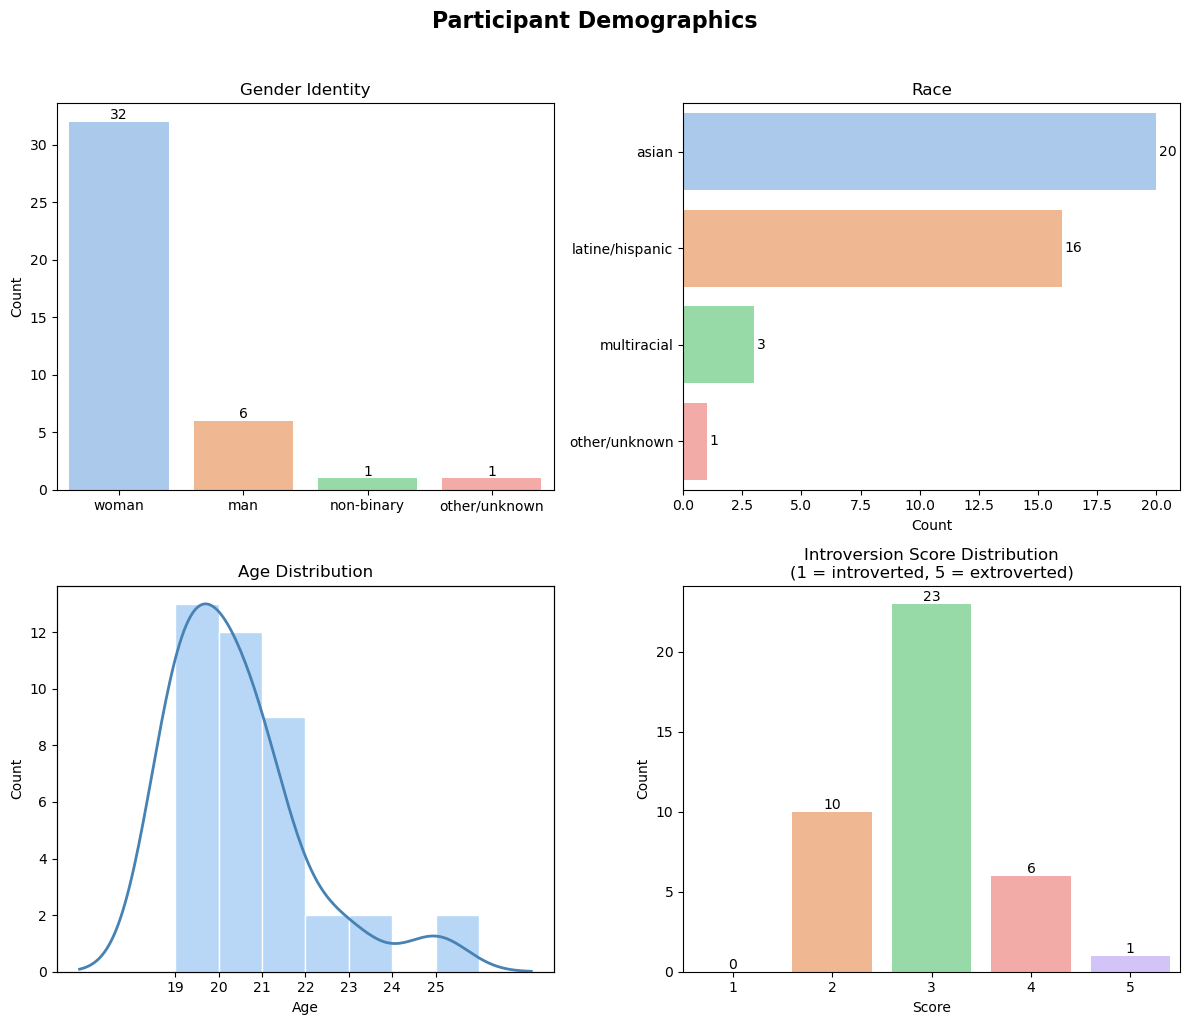

In [103]:
#first let's do an age distribution plot to see the age distribution of our participants:

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Participant Demographics', fontsize=16, fontweight='bold', y=1.02)

palette = sns.color_palette('pastel')

# 1) Gender → bar chart
gender_counts = survey_clean_df['gender'].value_counts()
sns.barplot(x=gender_counts.index, y=gender_counts.values, ax=axes[0, 0], palette='pastel')
axes[0, 0].set_title('Gender Identity')
axes[0, 0].set_xlabel('')
axes[0, 0].set_ylabel('Count')
for i, v in enumerate(gender_counts.values):
    axes[0, 0].text(i, v + 0.2, str(v), ha='center')

# 2) Race/Ethnicity
race_counts = survey_clean_df['race_ethnicity'].value_counts()
sns.barplot(x=race_counts.values, y=race_counts.index, ax=axes[0, 1], palette='pastel')
axes[0, 1].set_title('Race')
axes[0, 1].set_xlabel('Count')
axes[0, 1].set_ylabel('')
for i, v in enumerate(race_counts.values):
    axes[0, 1].text(v + 0.1, i, str(v), va='center')

# 3) Age distribution + KDE line
ax_age = axes[1, 0]
sns.histplot(survey_clean_df['age'], bins=range(19, 27), ax=ax_age, color=palette[0], edgecolor='white', stat='count')
ax_age.set_title('Age Distribution')
ax_age.set_xlabel('Age')
ax_age.set_ylabel('Count')
ax_age.set_xticks(range(19, 26))

# overlay a smooth KDE line scaled to counts
ax_kde = ax_age.twinx()
sns.kdeplot(survey_clean_df['age'], ax=ax_kde, color='steelblue', linewidth=2)
ax_kde.set_ylabel('')
ax_kde.set_yticks([])  # hide right y-axis ticks, line is just visual

# 4) Introversion score — fix x-axis to include 1
intro_counts = survey_clean_df['introversion_score'].value_counts().sort_index()
all_scores = pd.Series(0, index=range(1, 6))
all_scores.update(intro_counts)
sns.barplot(x=all_scores.index, y=all_scores.values, ax=axes[1, 1], palette='pastel')
axes[1, 1].set_title('Introversion Score Distribution\n(1 = introverted, 5 = extroverted)')
axes[1, 1].set_xlabel('Score')
axes[1, 1].set_ylabel('Count')
for i, v in enumerate(all_scores.values):
    axes[1, 1].text(i, v + 0.2, str(v), ha='center')

plt.tight_layout()
plt.savefig('../figures/demographics/demographics_overview.png', dpi=150, bbox_inches='tight')
plt.show()

In [104]:
# numerical summary of age and introversion score columns:
survey_clean_df[['age', 'introversion_score']].describe()


,age,introversion_score
count,40.000000,40.000000
mean,20.400000,2.950000
std,1.532553,0.714322
min,19.000000,2.000000
25%,19.000000,2.750000
50%,20.000000,3.000000
75%,21.000000,3.000000
max,25.000000,5.000000


In [105]:
survey_clean_df['gender'].value_counts()

gender
woman            32
man               6
non-binary        1
other/unknown     1
Name: count, dtype: int64

## Genre counts

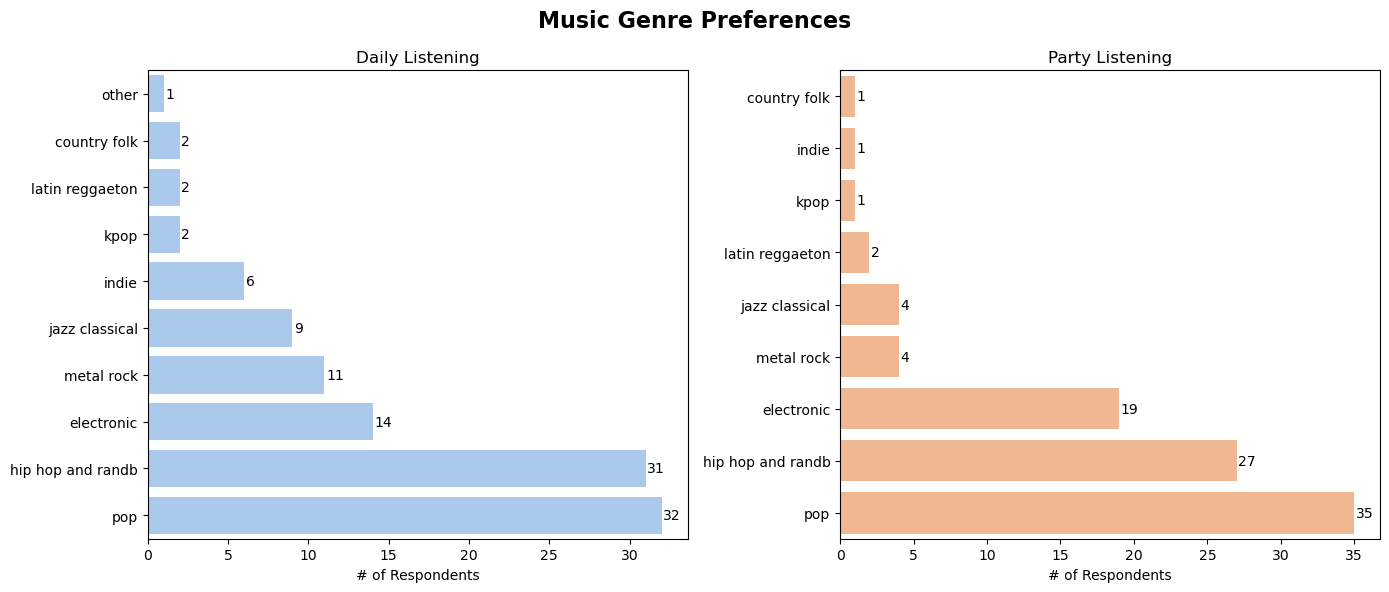

In [106]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Music Genre Preferences', fontsize=16, fontweight='bold')

palette = sns.color_palette('pastel')

# daily genre counts from indicator columns
daily_genres = {
    col.replace('genre_daily_', '').replace('_', ' '): survey_claude_df[col].sum()
    for col in survey_claude_df.columns if col.startswith('genre_daily_')
}
daily_series = pd.Series(daily_genres).sort_values(ascending=True)

# party genre counts from indicator columns
party_genres = {
    col.replace('genre_party_', '').replace('_', ' '): survey_claude_df[col].sum()
    for col in survey_claude_df.columns if col.startswith('genre_party_')
}
party_series = pd.Series(party_genres).sort_values(ascending=True)

# 1) Daily genres
sns.barplot(x=daily_series.values, y=daily_series.index, ax=axes[0], color=palette[0])
axes[0].set_title('Daily Listening')
axes[0].set_xlabel('# of Respondents')
axes[0].set_ylabel('')
for i, v in enumerate(daily_series.values):
    axes[0].text(v + 0.1, i, str(v), va='center')

# 2) Party genres
sns.barplot(x=party_series.values, y=party_series.index, ax=axes[1], color=palette[1])
axes[1].set_title('Party Listening')
axes[1].set_xlabel('# of Respondents')
axes[1].set_ylabel('')
for i, v in enumerate(party_series.values):
    axes[1].text(v + 0.1, i, str(v), va='center')

plt.tight_layout()
plt.savefig('../figures/genre_preferences.png', dpi=150, bbox_inches='tight')
plt.show()